## Crear un entorno Conda con requirements.txt
#### En la consola: conda create --name trabajo32 python=3.9 
#### En la consola: requirements.txt: pip install -r requirements.txt

----------------------------------------------------------------------
Análisis y Visualización de Logs de Seguridad Simulados - GRUPO 7
----------------------------------------------------------------------
Este script genera datos de logs de seguridad simulados y crea
visualizaciones para analizar la distribución de eventos, severidad,
actividad por hora, actividad sospechosa, intentos de login fallidos,
y la línea de tiempo de eventos críticos.
----------------------------------------------------------------------

Visualizaciones generadas correctamente. Revisa los archivos .png generados.


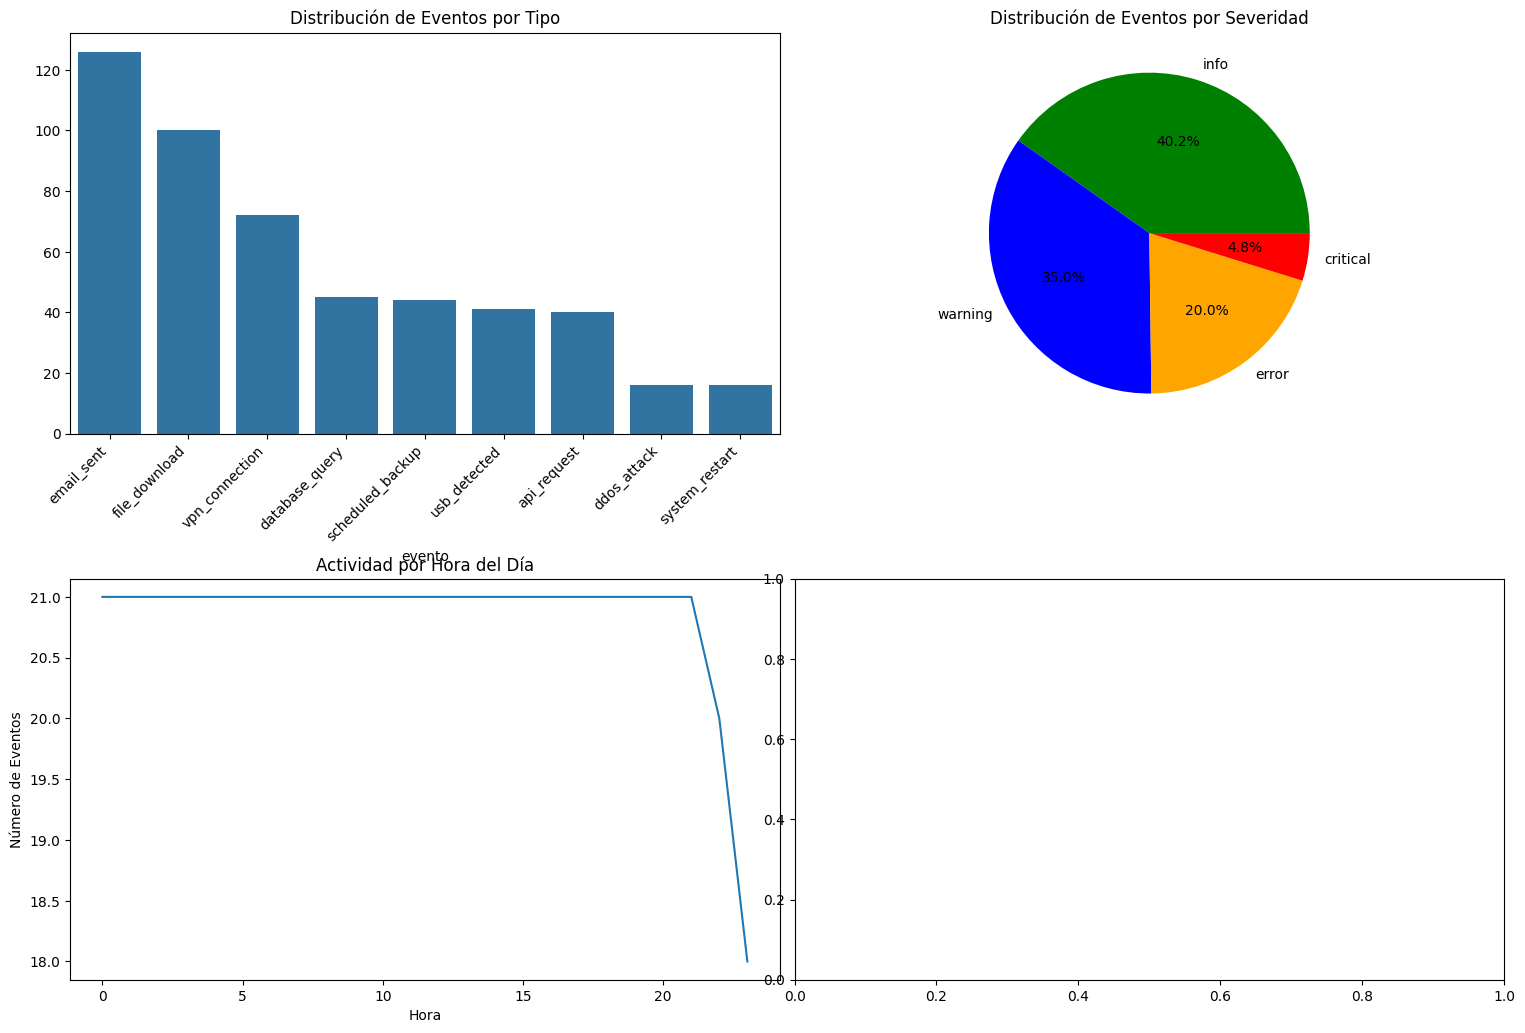

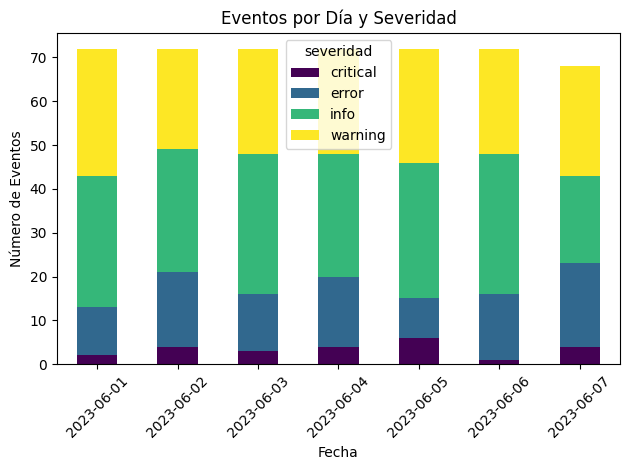

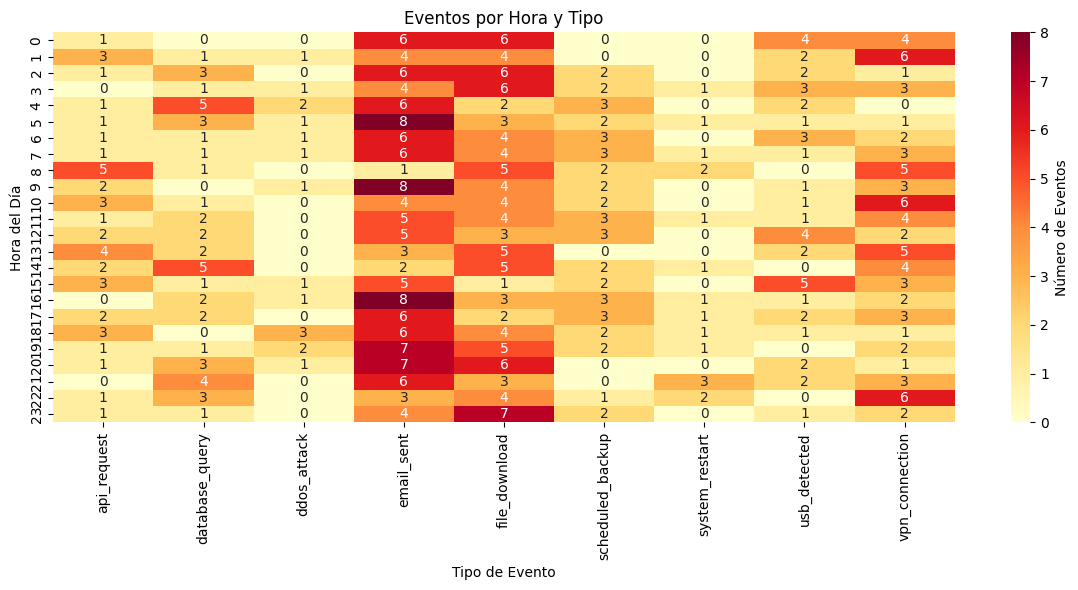

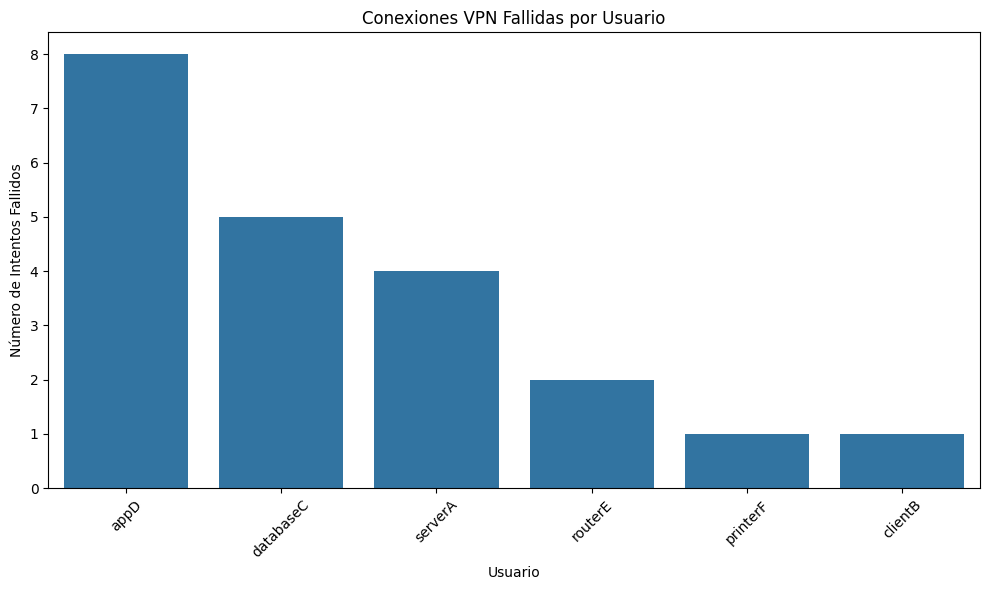

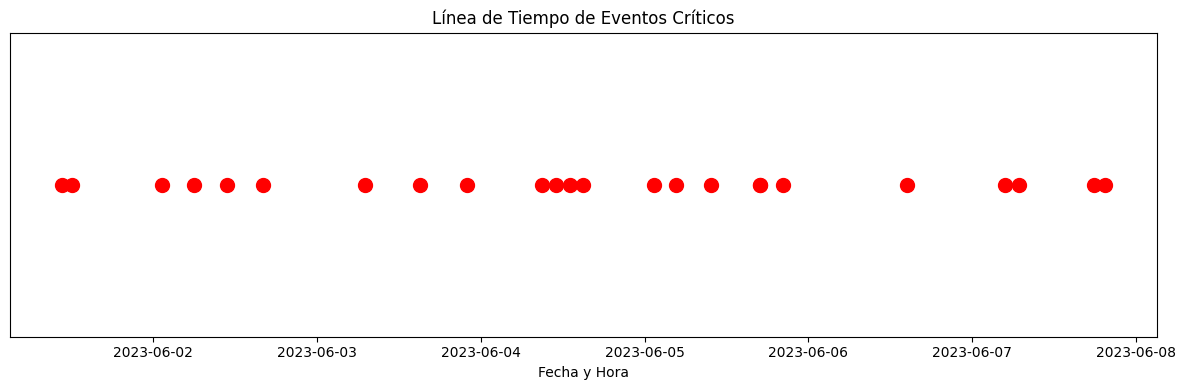

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("----------------------------------------------------------------------")
print("Análisis y Visualización de Logs de Seguridad Simulados - GRUPO 7")
print("----------------------------------------------------------------------")
print("Este script genera datos de logs de seguridad simulados y crea")
print("visualizaciones para analizar la distribución de eventos, severidad,")
print("actividad por hora, actividad sospechosa, intentos de login fallidos,")
print("y la línea de tiempo de eventos críticos.")
print("----------------------------------------------------------------------\n")
# Generar 500 registros de logs simulados con datos diferentes
np.random.seed(123)  # Cambiamos la semilla para obtener datos diferentes

# Lista de eventos de seguridad diferentes
eventos = ['email_sent', 'file_download', 'vpn_connection', 'database_query',
            'api_request', 'usb_detected', 'scheduled_backup',
            'ddos_attack', 'system_restart']

# Generar timestamps para una semana diferente
fechas = pd.date_range(start='2023-06-01', periods=7)
timestamps = []
for fecha in fechas:
    for hora in range(24):
        for _ in range(3):  # 3 eventos por hora aprox
            timestamps.append(fecha + pd.Timedelta(hours=hora) +
                              pd.Timedelta(minutes=np.random.randint(60)))

# Ajustar al número de registros deseados
timestamps = timestamps[:500]

# Generar IPs aleatorias diferentes
def random_ip():
    return f"{np.random.randint(10, 200)}.{np.random.randint(10, 200)}.{np.random.randint(10, 200)}.{np.random.randint(10, 200)}"

# Usuarios del sistema diferentes
usuarios = ['serverA', 'clientB', 'databaseC', 'appD', 'routerE', 'printerF', None]

# Generar datos simulados diferentes
data = {
    'timestamp': timestamps,
    'ip_origen': [random_ip() for _ in range(500)],
    'evento': np.random.choice(eventos, 500, p=[0.25, 0.2, 0.15, 0.1, 0.1, 0.08, 0.07, 0.03, 0.02]),
    'usuario': np.random.choice(usuarios, 500, p=[0.15, 0.18, 0.17, 0.16, 0.12, 0.11, 0.11]),
    'severidad': np.random.choice(['info', 'warning', 'error', 'critical'], 500, p=[0.4, 0.35, 0.2, 0.05]),
    'exitoso': np.random.choice([True, False], 500, p=[0.7, 0.3]),
}

# Crear DataFrame
logs_df = pd.DataFrame(data)

# Configurar timestamp como índice
logs_df['timestamp'] = pd.to_datetime(logs_df['timestamp'])
logs_df = logs_df.sort_values('timestamp')

# Ahora creamos las visualizaciones (igual que antes)
plt.figure(figsize=(15, 10))

# 1. Distribución de eventos por tipo
plt.subplot(2, 2, 1)
eventos_count = logs_df['evento'].value_counts()
sns.barplot(x=eventos_count.index, y=eventos_count.values)
plt.xticks(rotation=45, ha='right')
plt.title('Distribución de Eventos por Tipo')
plt.tight_layout()

# 2. Distribución de eventos por severidad
plt.subplot(2, 2, 2)
severidad_count = logs_df['severidad'].value_counts()
colors = {'info': 'green', 'warning': 'blue', 'error': 'orange', 'critical': 'red'}
plt.pie(severidad_count, labels=severidad_count.index, autopct='%1.1f%%',
        colors=[colors[sev] for sev in severidad_count.index])
plt.title('Distribución de Eventos por Severidad')

# 3. Actividad por hora del día
plt.subplot(2, 2, 3)
logs_df['hour'] = logs_df['timestamp'].dt.hour
hourly_count = logs_df.groupby('hour').size()
sns.lineplot(x=hourly_count.index, y=hourly_count.values)
plt.title('Actividad por Hora del Día')
plt.xlabel('Hora')
plt.ylabel('Número de Eventos')

# 4. Eventos por día y por severidad
plt.subplot(2, 2, 4)
logs_df['date'] = logs_df['timestamp'].dt.date
pivot_table = pd.crosstab(logs_df['date'], logs_df['severidad'])
pivot_table.plot(kind='bar', stacked=True, colormap='viridis')
plt.title('Eventos por Día y Severidad')
plt.xlabel('Fecha')
plt.ylabel('Número de Eventos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('security_dashboard_2.png')

# Crear gráfico de actividad sospechosa
plt.figure(figsize=(12, 6))

# 5. Mapa de calor de actividad por hora y tipo de evento
logs_df['hour'] = logs_df['timestamp'].dt.hour
heatmap_data = pd.crosstab(logs_df['hour'], logs_df['evento'])
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt='d', cbar_kws={'label': 'Número de Eventos'})
plt.title('Eventos por Hora y Tipo')
plt.xlabel('Tipo de Evento')
plt.ylabel('Hora del Día')
plt.tight_layout()
plt.savefig('activity_heatmap_2.png')

# 6. Análisis de accesos fallidos por usuario
plt.figure(figsize=(10, 6))
failed_logins = logs_df[(logs_df['evento'] == 'vpn_connection') & (logs_df['exitoso'] == False)]
user_failures = failed_logins['usuario'].value_counts()
sns.barplot(x=user_failures.index.fillna('anónimo'), y=user_failures.values)
plt.title('Conexiones VPN Fallidas por Usuario')
plt.xlabel('Usuario')
plt.ylabel('Número de Intentos Fallidos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('failed_logins_by_user_2.png')

# 7. Línea de tiempo de eventos críticos
plt.figure(figsize=(12, 4))
critical_events = logs_df[logs_df['severidad'] == 'critical']
plt.scatter(critical_events['timestamp'], [1]*len(critical_events), c='red', s=100)
plt.yticks([])
plt.title('Línea de Tiempo de Eventos Críticos')
plt.xlabel('Fecha y Hora')
plt.tight_layout()
plt.savefig('critical_events_timeline_2.png')

print("Visualizaciones generadas correctamente. Revisa los archivos .png generados.")
